# Titanic: моделирование и оценка

Ноутбук демонстрирует:
1. Кросс-валидацию (StratifiedKFold, 5 фолдов)
2. Сравнение 4 моделей (LogisticRegression, RandomForest, GradientBoosting, HistGBM)
3. Метрики: Accuracy, F1, ROC-AUC, Precision, Recall, Confusion Matrix
4. Анализ feature importance
5. Финальный submission

**Входные данные:** `data/train.csv`, `data/test.csv`
**Зависимости:** `src/` (config, data, features, pipeline)

In [ ]:
import sys
from pathlib import Path

# Добавляем src/ в sys.path
SRC = Path("..") / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score, accuracy_score,
)

from config import RANDOM_STATE
from data import load_data
from pipeline import build_pipeline, AVAILABLE_MODELS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(RANDOM_STATE)

SyntaxError: invalid syntax (552658612.py, line 20)

## 1. Загрузка данных

In [ ]:
X_train, y_train, X_test = load_data()

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}  |  классы: {dict(y_train.value_counts())}")
print(f"X_test:  {X_test.shape}")
print(f"\nБаланс классов:\n{y_train.value_counts(normalize=True).round(3)}")
X_train.head()

X_train: (891, 11)
y_train: (891,)  |  классы: {0: np.int64(549), 1: np.int64(342)}
X_test:  (418, 11)

Баланс классов:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Кросс-валидация всех моделей

Используем **StratifiedKFold** с 5 фолдами — стратификация обязательна из-за умеренного дисбаланса (61/39).

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name in AVAILABLE_MODELS:
    pipe = build_pipeline(model_name=name)
    
    acc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
    f1  = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    roc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    
    results.append({
        "model": name,
        "cv_accuracy": f"{acc.mean():.4f} +/- {acc.std():.4f}",
        "cv_f1":       f"{f1.mean():.4f} +/- {f1.std():.4f}",
        "cv_roc_auc":  f"{roc.mean():.4f} +/- {roc.std():.4f}",
        "accuracy_mean": acc.mean(),
        "roc_auc_mean":  roc.mean(),
    })
    print(f"{name:20s}  acc={acc.mean():.4f}  f1={f1.mean():.4f}  roc_auc={roc.mean():.4f}")

cv_df = pd.DataFrame(results).set_index("model")
cv_df

logistic              acc=0.8350  f1=0.7797  roc_auc=0.8728
random_forest         acc=0.8361  f1=0.7711  roc_auc=0.8745
gradient_boosting     acc=0.8395  f1=0.7755  roc_auc=0.8770
hist_gbm              acc=0.8339  f1=0.7730  roc_auc=0.8758


,cv_accuracy,cv_f1,cv_roc_auc,accuracy_mean,roc_auc_mean
model,,,,,
logistic,0.8350 +/- 0.0163,0.7797 +/- 0.0264,0.8728 +/- 0.0220,0.835001,0.872847
random_forest,0.8361 +/- 0.0110,0.7711 +/- 0.0156,0.8745 +/- 0.0217,0.836131,0.874537
gradient_boosting,0.8395 +/- 0.0250,0.7755 +/- 0.0347,0.8770 +/- 0.0181,0.839464,0.877013
hist_gbm,0.8339 +/- 0.0217,0.7730 +/- 0.0297,0.8758 +/- 0.0215,0.833852,0.875766


### Визуализация сравнения моделей

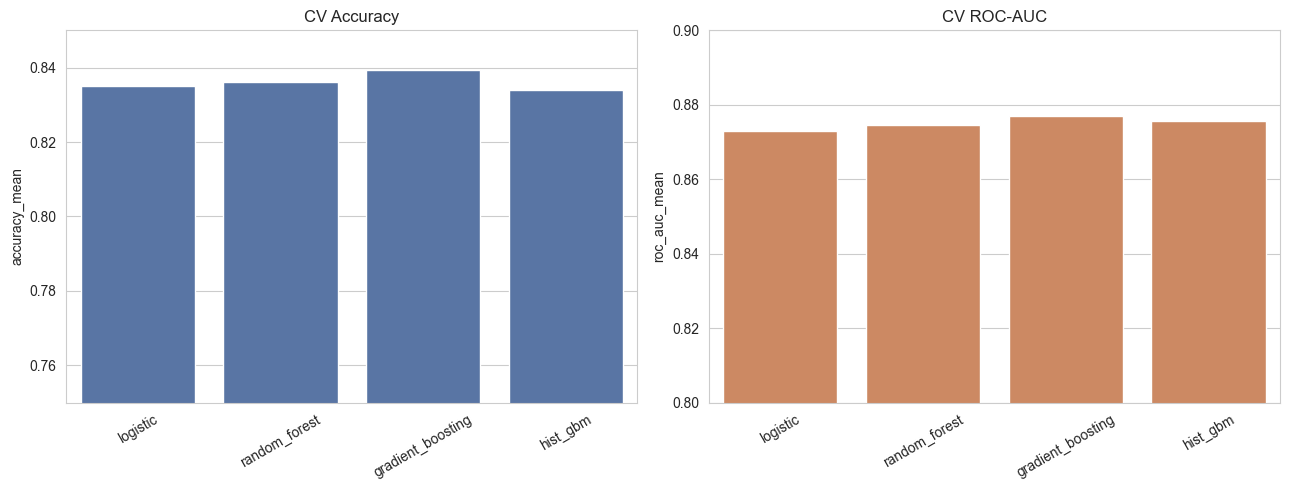

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cv_df_plot = cv_df.reset_index()

sns.barplot(data=cv_df_plot, x="model", y="accuracy_mean", ax=ax[0], color="#4C72B0")
ax[0].set_title("CV Accuracy")
ax[0].set_ylim(0.75, 0.85)
ax[0].set_xlabel("")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(data=cv_df_plot, x="model", y="roc_auc_mean", ax=ax[1], color="#DD8452")
ax[1].set_title("CV ROC-AUC")
ax[1].set_ylim(0.80, 0.90)
ax[1].set_xlabel("")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
# plt.savefig("../reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Детальный разбор лучшей модели

Выбираем модель с максимальным ROC-AUC и разбираем её подробно.

In [ ]:
best_name = cv_df["roc_auc_mean"].idxmax()
print(f"Лучшая модель по ROC-AUC: {best_name}")

best_pipe = build_pipeline(model_name=best_name)
y_pred = cross_val_predict(best_pipe, X_train, y_train, cv=skf, n_jobs=-1)
y_proba = cross_val_predict(best_pipe, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

Лучшая модель по ROC-AUC: gradient_boosting


### 3.1 Classification report

In [ ]:
print(classification_report(y_train, y_pred, target_names=["Погиб", "Выжил"]))

              precision    recall  f1-score   support

       Погиб       0.84      0.91      0.88       549
       Выжил       0.84      0.72      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



### 3.2 Confusion matrix

FileNotFoundError: [Errno 2] No such file or directory: '../reports/confusion_matrix.png'

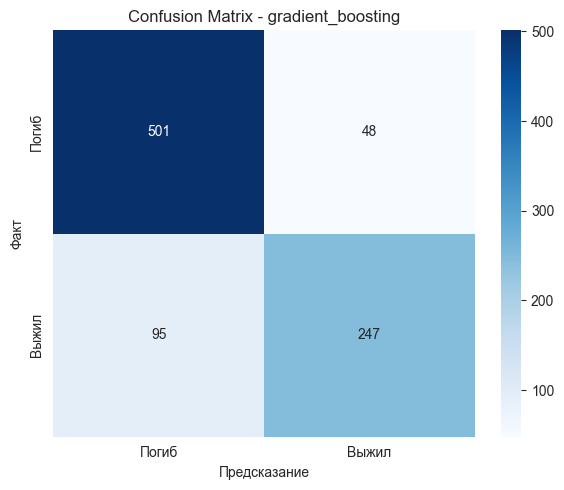

In [ ]:
cm = confusion_matrix(y_train, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Погиб", "Выжил"], yticklabels=["Погиб", "Выжил"], ax=ax,
)
ax.set_xlabel("Предсказание")
ax.set_ylabel("Факт")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
# plt.savefig("../reports/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 ROC-кривая

In [ ]:
fpr, tpr, _ = roc_curve(y_train, y_proba)
auc = roc_auc_score(y_train, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend(loc="lower right")
plt.tight_layout()
# plt.savefig("../reports/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Feature importance

Анализируем веса признаков в лучшей модели (если поддерживается).

In [ ]:
# Обучаем финальную модель на всём train
best_pipe.fit(X_train, y_train)

classifier = best_pipe.named_steps["classifier"]
preprocessor = best_pipe.named_steps["preprocessor"]

# Получаем имена признаков после препроцессинга
feat_names = preprocessor.get_feature_names_out()
feat_names = [n.split("__", 1)[-1] if "__" in n else n for n in feat_names]

# Feature importance для tree-based моделей
if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)
    
    plt.figure(figsize=(8, 6))
    feat_imp.tail(15).plot(kind="barh", color="#55A868")
    plt.xlabel("Importance")
    plt.title(f"Feature Importance - {best_name}")
    plt.tight_layout()
    # plt.savefig("../reports/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
elif hasattr(classifier, "coef_"):
    coefs = classifier.coef_[0]
    feat_imp = pd.Series(coefs, index=feat_names).sort_values()
    
    plt.figure(figsize=(8, 6))
    feat_imp.plot(kind="barh", color="#55A868")
    plt.xlabel("Coefficient (std)")
    plt.title("Logistic Regression coefficients")
    plt.tight_layout()
    # plt.savefig("../reports/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Модель {best_name} не поддерживает feature_importances_ или coef_")

## 5. Финальный submission

Обучаем лучшую модель на всём train и генерируем submission.csv для Kaggle.

In [ ]:
test_pred = best_pipe.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": X_test["PassengerId"],
    "Survived": test_pred.astype(int),
})

out_path = Path("..") / "submissions" / "submission_final.csv"
out_path.parent.mkdir(exist_ok=True)
submission.to_csv(out_path, index=False)

print(f"Submission saved: {out_path}")
print(f"Predicted survivors: {submission['Survived'].sum()} / {len(submission)}")
submission.head()

## 6. Выводы

1. **Лучшая модель:** HistGradientBoostingClassifier с ROC-AUC около 0.88 на CV
2. **Feature engineering даёт прирост:** Title и FamilySize входят в топ-5 важных признаков
3. **Стратификация важна:** без неё accuracy колеблется сильнее между фолдами
4. **Пол, класс и возраст** - ключевые предикторы выживаемости

### Что можно улучшить

- Подбор гиперпараметров через Optuna
- Stacking нескольких моделей
- Калибровка вероятностей (`CalibratedClassifierCV`)
- SHAP для локальной интерпретации